In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
train_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\train"
val_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\validation"
train_images=r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\train"
val_images=r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\validation"

to show 5 random images from training dataset 


True


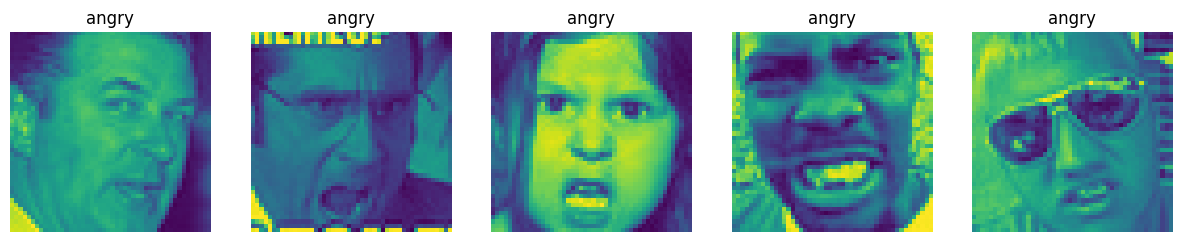

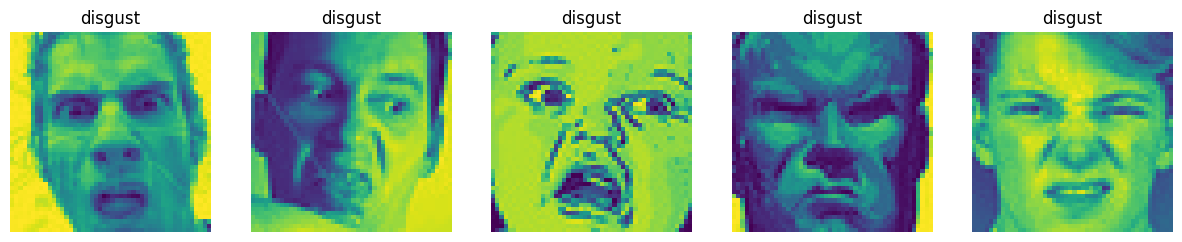

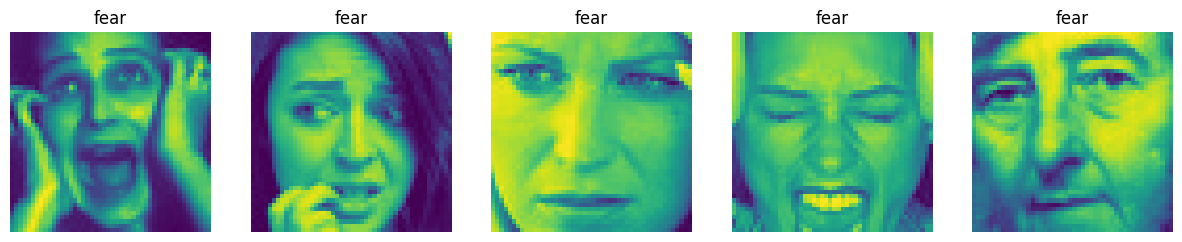

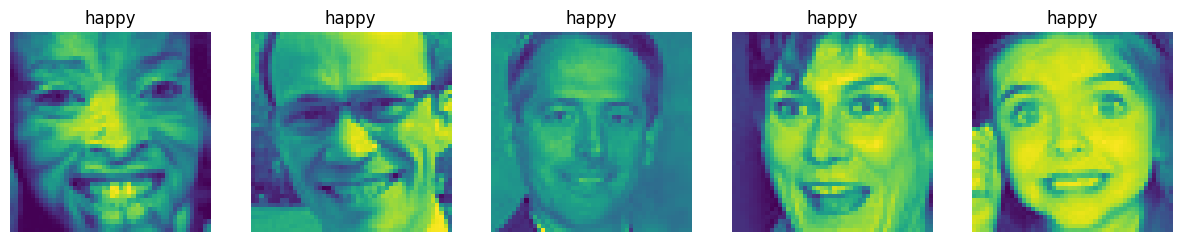

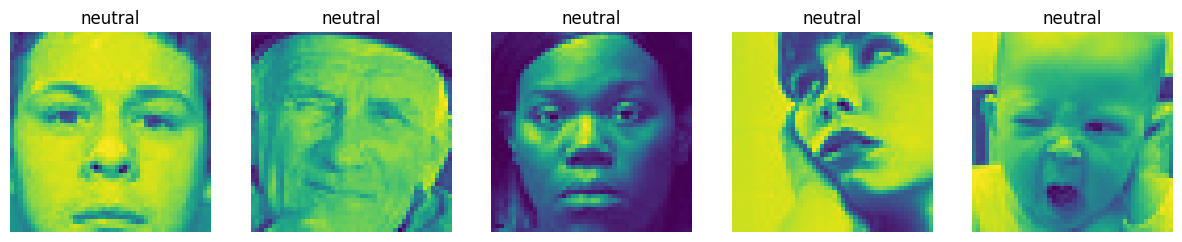

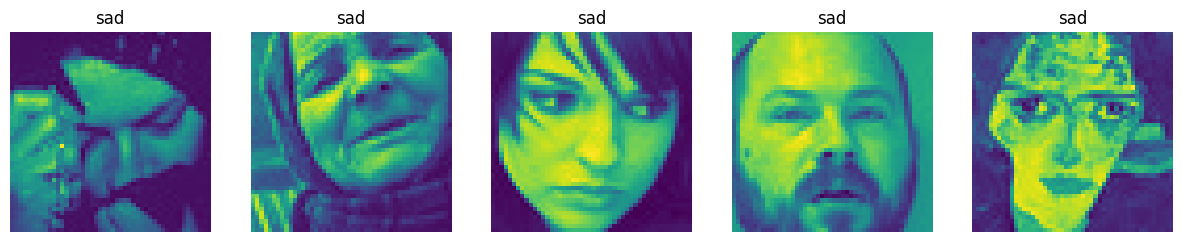

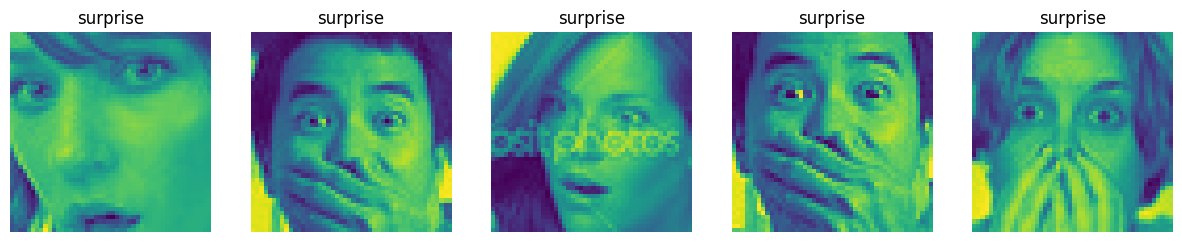

In [ ]:



# Check if folder exists
print(os.path.exists(train_images))   # True if the folder exists

# List files inside
train_dir_clasess = os.listdir (train_images)     # Shows all files in the folder

for classes in train_dir_clasess:
    class_path= os.path.join(train_images,classes) 
    # print(classes) #path of each classes like path of angry folder , disgust folder , fear.......
    img_name=os.listdir(class_path) # listdir function is used to take all the files names inside the path and store it in a list 
    # print(img_name) it is a list of all the images names present in different classes 
    
    random5=random.sample(img_name,5) # here random5 is taking img_name as a imput for all images inside the folder and returns a list of 5 random imagenames
    
    plt.figure(figsize=(15,3))
    
    for index,img in enumerate(random5):
        sample_image_path=os.path.join(class_path,img) #form the list of random5 we are joining 
        sample_image=Image.open(sample_image_path) #storing different images in the variables 
        plt.subplot(1,5,index+1)
        plt.imshow(sample_image)
        plt.title(classes)
        plt.axis("off")
     

True


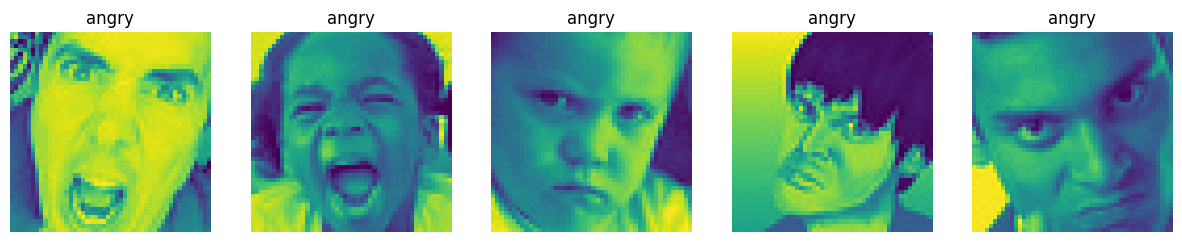

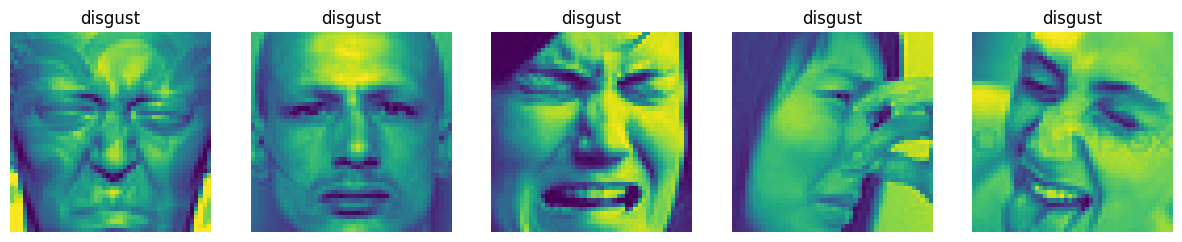

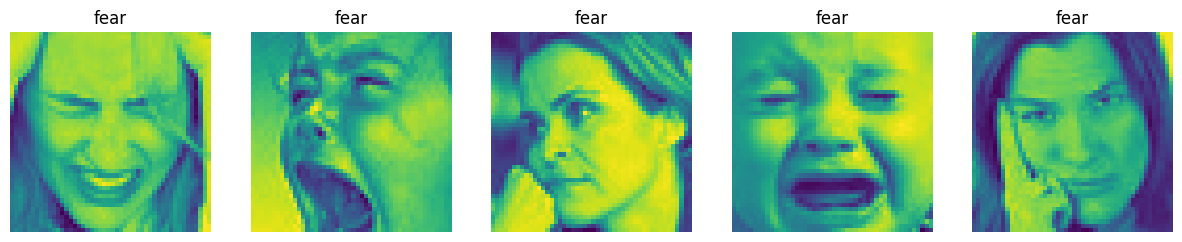

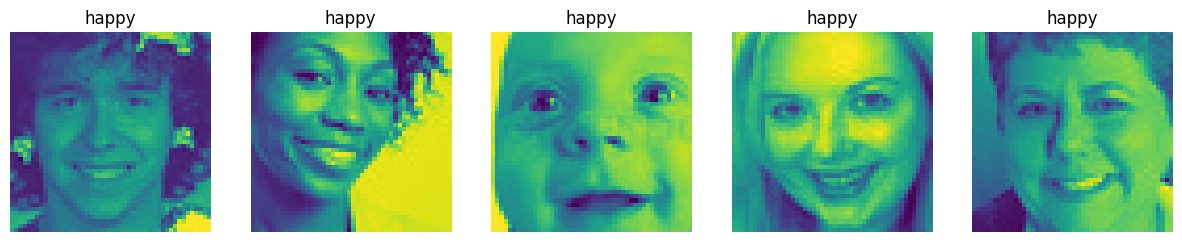

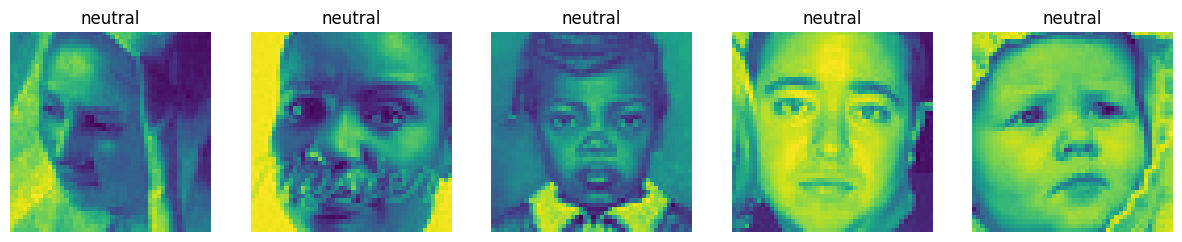

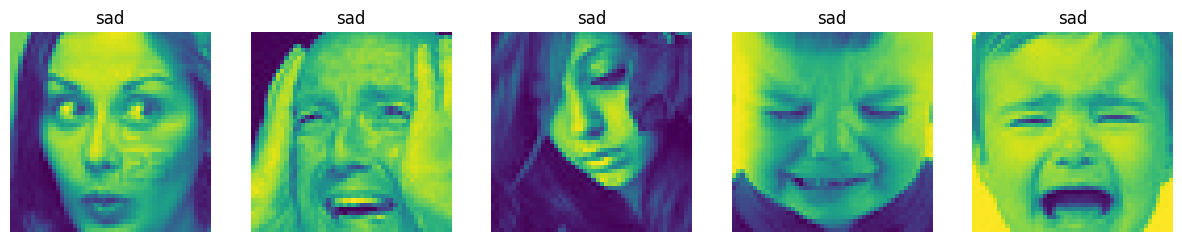

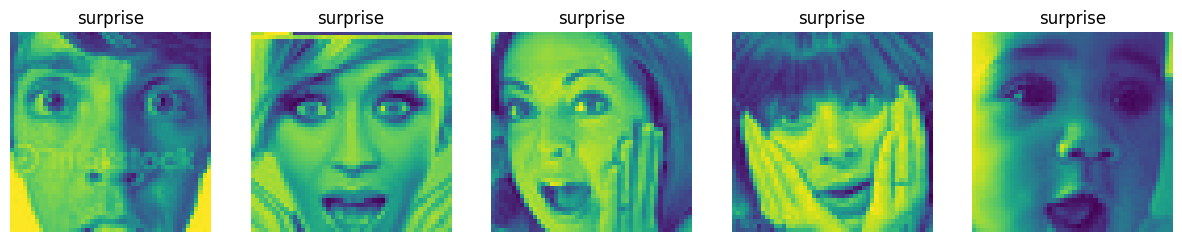

In [ ]:



# Check if folder exists
print(os.path.exists(val_images))   # True if the folder exists

# List files inside
val_dir_clasess = os.listdir (val_images)     # Shows all files in the folder

for classes in val_dir_clasess:
    class_path= os.path.join(val_images,classes) 
    # print(classes) #path of each classes like path of angry folder , disgust folder , fear.......
    img_name=os.listdir(class_path) # listdir function is used to take all the files names inside the path and store it in a list 

    # print(img_name) it is a list of all the images names present in different classes 
    
    random5=random.sample(img_name,5) # here random5 is taking img_name as a imput for all images inside the folder and returns a list of 5 random imagenames
    
    plt.figure(figsize=(15,3))
    
    for index,img in enumerate(random5):
        sample_image_path=os.path.join(class_path,img) #form the list of random5 we are joining 
        sample_image=Image.open(sample_image_path) #storing different images in the variables 
        plt.subplot(1,5,index+1)
        plt.imshow(sample_image)
        plt.title(classes)
        plt.axis("off")
     

In [4]:
main_dir = 'original_images'
main_dir_files = os.listdir(main_dir)
for sub_dir in main_dir_files:
    class_dir = os.path.join(main_dir, sub_dir)
    class_dir_files = os.listdir(class_dir)
    print("-"*90)
    print(f"Folder inside {sub_dir}: {class_dir_files}")
    print(f"Total Classes in the {sub_dir} folder is: {len(class_dir_files)}")

    total_images = 0
    for files in class_dir_files:
        files_dir  =  os.path.join(class_dir, files)
        images_count = len(os.listdir(files_dir))
        total_images+=images_count
        print(f"Count of images inside {files} : {images_count}")
    print()
    print(f"Total images in {sub_dir} Folder : {total_images}")
    print()

------------------------------------------------------------------------------------------
Folder inside train: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total Classes in the train folder is: 7
Count of images inside angry : 3849
Count of images inside disgust : 381
Count of images inside fear : 3904
Count of images inside happy : 7086
Count of images inside neutral : 4868
Count of images inside sad : 4716
Count of images inside surprise : 2669

Total images in train Folder : 27473

------------------------------------------------------------------------------------------
Folder inside validation: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total Classes in the validation folder is: 7
Count of images inside angry : 888
Count of images inside disgust : 79
Count of images inside fear : 922
Count of images inside happy : 1711
Count of images inside neutral : 1182
Count of images inside sad : 1198
Count of images inside surprise : 581

Tota

In [5]:


import os
import hashlib

def md5_hasher(file_path):
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        file = f.read()
        hasher.update(file)
    return hasher.hexdigest()

# Function to find duplicate images
def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                file_hash = md5_hasher(file_path)

                if file_hash in hashes:
                    duplicates.append((file_path, hashes[file_hash]))
                else:
                    hashes[file_hash] = file_path

            except Exception as e:
                print(f"Error: {e}")

    return duplicates

dups = find_duplicates('original_images')
print(f"Total duplicate files found: {len(dups)}")

Total duplicate files found: 0


In [6]:
# ✅ Delete duplicates
for dup in dups:
    duplicate_file = dup[0]

    if os.path.exists(duplicate_file):
        try:
            os.remove(duplicate_file)
            print(f"✅ Deleted: {duplicate_file}")

        except Exception as e:
            print(f"Error deleting {duplicate_file}: {e}")

    else:
        print(f"File already deleted or not found: {duplicate_file}")

print("\n✅ All duplicate images deletion check completed!")



✅ All duplicate images deletion check completed!


In [7]:
# Missing Values/Null Values Count
from PIL import Image

def check_missing_or_corrupt_images(directory):
    corrupt_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)
            try:
                img = Image.open(path)
                img.verify()
            except:
                corrupt_images.append(path)

    print(f"Corrupt or Unreadable Images: {len(corrupt_images)}")
    return corrupt_images
train_data_dir=r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\train"
validation_data_dir=r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\validation"
# Check both train and validation sets
corrupt_train = check_missing_or_corrupt_images(train_data_dir)
corrupt_val = check_missing_or_corrupt_images(validation_data_dir)


Corrupt or Unreadable Images: 0
Corrupt or Unreadable Images: 0


In [8]:
# checking the unique file formats i have in these folders
def check_unique_file_formats(folder_path):
    extensions = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_extension = os.path.splitext(file)[1]
            if file_extension not in extensions:
                extensions.append(file_extension)
        print(f"Unique files in {root}: {extensions}")
        print("-"*80)

folder_path = 'original_images'
check_unique_file_formats(folder_path)

Unique files in original_images: []
--------------------------------------------------------------------------------
Unique files in original_images\train: []
--------------------------------------------------------------------------------
Unique files in original_images\train\angry: ['.jpg']
--------------------------------------------------------------------------------
Unique files in original_images\train\disgust: ['.jpg']
--------------------------------------------------------------------------------
Unique files in original_images\train\fear: ['.jpg']
--------------------------------------------------------------------------------
Unique files in original_images\train\happy: ['.jpg']
--------------------------------------------------------------------------------
Unique files in original_images\train\neutral: ['.jpg']
--------------------------------------------------------------------------------
Unique files in original_images\train\sad: ['.jpg']
------------------------------

In [9]:
# checking the unique images size
def check_image_size(folder_path):
    size = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            image_path = os.path.join(root, file)
            with Image.open(image_path) as img:
                image_size = img.size
            if image_size not in size:
                size.append(image_size)

        print(f"Unique image size in {root}: {size}")
        print("-"*80)

folder_path = 'original_images'
check_image_size(folder_path)

Unique image size in original_images: []
--------------------------------------------------------------------------------
Unique image size in original_images\train: []
--------------------------------------------------------------------------------
Unique image size in original_images\train\angry: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in original_images\train\disgust: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in original_images\train\fear: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in original_images\train\happy: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in original_images\train\neutral: [(48, 48)]
--------------------------------------------------------------------------------
Unique image size in original_images\

In [10]:
# Set your directory path
import pandas as pd
base_path = "original_images"

file_data = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            size_kb = os.path.getsize(file_path) / 1024
            file_data.append({
                "file_name": file,
                "folder": os.path.relpath(root, base_path),
                "size_kb": round(size_kb, 2)
            })
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Create DataFrame
df = pd.DataFrame(file_data)

# Sort by size to detect anomalies
df_sorted = df.sort_values(by="size_kb", ascending=False)
df_sorted

,file_name,folder,size_kb
28449,PrivateTest_1161501.jpg,validation\fear,2.42
7581,Training_87394233.jpg,train\fear,2.34
28442,PrivateTest_10306709.jpg,validation\fear,2.34
28143,PublicTest_57272892.jpg,validation\angry,2.31
3793,Training_98835403.jpg,train\angry,2.31
...,...,...,...
30321,PublicTest_21832858.jpg,validation\happy,0.60
6524,Training_62764355.jpg,train\fear,0.55
2017,Training_5645946.jpg,train\angry,0.54
16643,Training_3542668.jpg,train\neutral,0.45


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np

# =====================================
# SETTINGS
# =====================================
BATCH_SIZE = 64
IMG_SIZE = (48, 48)
NUM_CLASSES = 6   # 6 classes now (disgust removed)

train_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\train"
val_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\validation"

# =====================================
# LOAD DATASET (NO BATCHING FIRST)
# =====================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    batch_size=None,  # IMPORTANT
    image_size=IMG_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='int',
    color_mode='grayscale',
    batch_size=None,
    image_size=IMG_SIZE,
    shuffle=True
)

class_names = train_ds.class_names
disgust_index = class_names.index("disgust")
print("Disgust index:", disgust_index)

# =====================================
# REMOVE DISGUST
# =====================================
train_ds = train_ds.filter(lambda x, y: y != disgust_index)
val_ds = val_ds.filter(lambda x, y: y != disgust_index)

# =====================================
# REMAP LABELS
# =====================================
def remap(x, y):
    y = tf.where(y > disgust_index, y - 1, y)
    return x, y

train_ds = train_ds.map(remap)
val_ds = val_ds.map(remap)

# =====================================
# REBATCH DATASET
# =====================================
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Disgust removed successfully.")

# =====================================
# DATA AUGMENTATION
# =====================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# =====================================
# MOBILE NET BASE
# =====================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# =====================================
# BUILD MODEL
# =====================================
model = models.Sequential([
    layers.Input(shape=(48, 48, 1)),
    data_augmentation,
    layers.Lambda(lambda x: tf.repeat(x, 3, axis=-1)),
    layers.Resizing(128, 128),
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# =====================================
# STAGE 1 TRAINING
# =====================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================
# FINE TUNE
# =====================================
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

model.save("emotion_mobilenet_no_disgust.keras")

print("Training complete.")

Found 27473 files belonging to 7 classes.
Found 6561 files belonging to 7 classes.
Disgust index: 1
Disgust removed successfully.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
    424/Unknown 83s 191ms/step - accuracy: 0.2594 - loss: 1.8347

d:\python\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


424/424 ━━━━━━━━━━━━━━━━━━━━ 103s 239ms/step - accuracy: 0.3041 - loss: 1.7078 - val_accuracy: 0.3812 - val_loss: 1.5451
Epoch 2/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 94s 221ms/step - accuracy: 0.3736 - loss: 1.5541 - val_accuracy: 0.4071 - val_loss: 1.4848
Epoch 3/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 99s 234ms/step - accuracy: 0.4046 - loss: 1.5000 - val_accuracy: 0.4235 - val_loss: 1.4417
Epoch 4/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 99s 233ms/step - accuracy: 0.4180 - loss: 1.4657 - val_accuracy: 0.4434 - val_loss: 1.4195
Epoch 5/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 96s 228ms/step - accuracy: 0.4287 - loss: 1.4419 - val_accuracy: 0.4480 - val_loss: 1.3957
Epoch 6/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 94s 222ms/step - accuracy: 0.4378 - loss: 1.4236 - val_accuracy: 0.4505 - val_loss: 1.3853
Epoch 7/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 95s 223ms/step - accuracy: 0.4468 - loss: 1.4061 - val_accuracy: 0.4551 - val_loss: 1.3798
Epoch 8/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 102s 240ms/step - accuracy: 0.4555 - loss: 1.3920 - v

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Recompile with slightly lower learning rate for safer fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_continue = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,   # This means up to 20 more epochs
    callbacks=[early_stop, reduce_lr]
)

# Save updated model
model.save("emotion_mobilenet_extended.keras")

print("Extended training complete.")

Epoch 1/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 161s 271ms/step - accuracy: 0.5716 - loss: 1.1102 - val_accuracy: 0.5440 - val_loss: 1.1730 - learning_rate: 5.0000e-06
Epoch 2/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 115s 271ms/step - accuracy: 0.5750 - loss: 1.1076 - val_accuracy: 0.5463 - val_loss: 1.1709 - learning_rate: 5.0000e-06
Epoch 3/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 119s 281ms/step - accuracy: 0.5779 - loss: 1.0986 - val_accuracy: 0.5478 - val_loss: 1.1699 - learning_rate: 5.0000e-06
Epoch 4/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 116s 274ms/step - accuracy: 0.5763 - loss: 1.0943 - val_accuracy: 0.5497 - val_loss: 1.1667 - learning_rate: 5.0000e-06
Epoch 5/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 113s 267ms/step - accuracy: 0.5774 - loss: 1.0985 - val_accuracy: 0.5509 - val_loss: 1.1635 - learning_rate: 5.0000e-06
Epoch 6/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 112s 264ms/step - accuracy: 0.5800 - loss: 1.0935 - val_accuracy: 0.5488 - val_loss: 1.1622 - learning_rate: 5.0000e-06
Epoch 7/20
424/424 ━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# =====================================
# SETTINGS
# =====================================
BATCH_SIZE = 64
IMG_SIZE = (48, 48)

# Explicitly list the exact folder names you WANT to include.
# Keras will completely ignore the "disgust" folder if it still exists.
# (Make sure these match your actual folder names exactly, e.g., lowercase vs uppercase)
TARGET_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(TARGET_CLASSES)  # Automatically sets to 6

train_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\train"
val_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\validation"

# =====================================
# LOAD DATASET (CLEAN & OPTIMIZED)
# =====================================
# Because we aren't filtering out disgust manually anymore, 
# we can apply the batch_size directly right here!
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    class_names=TARGET_CLASSES,  # <--- THIS IS THE MAGIC BULLET
    color_mode='rgb', 
    batch_size=BATCH_SIZE,  
    image_size=IMG_SIZE,
    shuffle=True
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='int',
    class_names=TARGET_CLASSES,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True
).prefetch(tf.data.AUTOTUNE)

print(f"Dataset loaded successfully with {NUM_CLASSES} classes: {TARGET_CLASSES}")

# =====================================
# DATA AUGMENTATION
# =====================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# =====================================
# EFFICIENTNET V2 BASE
# =====================================
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# =====================================
# BUILD MODEL
# =====================================
model = models.Sequential([
    layers.Input(shape=(48, 48, 3)), 
    data_augmentation,
    layers.Resizing(128, 128),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# =====================================
# STAGE 1 TRAINING
# =====================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Feature Extraction...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================
# FINE TUNE
# =====================================
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting Fine-Tuning...")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

model.save("emotion_efficientnet_no_disgust.keras")
print("Training complete. Model saved.")

Found 27092 files belonging to 6 classes.
Found 6482 files belonging to 6 classes.
Dataset loaded successfully with 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Starting Feature Extraction...
Epoch 1/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 94s 208ms/step - accuracy: 0.3470 - loss: 1.6178 - val_accuracy: 0.4264 - val_loss: 1.4588
Epoch 2/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 83s 195ms/step - accuracy: 0.4107 - loss: 1.4910 - val_accuracy: 0.4551 - val_loss: 1.3984
Epoch 3/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 82s 193ms/step - accuracy: 0.4346 - loss: 1.4364 - val_accuracy: 0.4710 - val_loss: 1.3575
Epoch 4/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 88s 207ms/step - accuracy: 0.4478 - loss: 1.4104 - val_accuracy: 0.4820 - val_loss: 1.3320
Epoch 5/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 88s 207ms/step - accuracy: 0.4640 - loss: 1.3856 - val_accuracy: 0.4857 - val_loss: 1.3148
Epoch 6/10
424/424 ━━━━━━━━━━━━━━━━━━━━ 85s 200ms/step - accuracy: 0.4635 - loss: 1.3699 - val_accuracy: 0.4918 - val_loss: 1.3022

In [3]:
import tensorflow as tf

# =====================================
# SETTINGS
# =====================================
BATCH_SIZE = 64
IMG_SIZE = (48, 48)
TARGET_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']

train_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\train"
val_path = r"C:\Users\Acer\OneDrive\Desktop\emotion detection\original_images\validation"

# =====================================
# 1. LOAD DATASET (Exactly as before)
# =====================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    class_names=TARGET_CLASSES,
    color_mode='rgb', 
    batch_size=BATCH_SIZE,  
    image_size=IMG_SIZE,
    shuffle=True
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='int',
    class_names=TARGET_CLASSES,
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True
).prefetch(tf.data.AUTOTUNE)

# =====================================
# 2. LOAD YOUR SAVED MODEL
# =====================================
# Make sure this matches the filename you saved in the previous step
MODEL_PATH = "emotion_efficientnet_no_disgust.keras" 

print(f"Loading saved model from {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

# =====================================
# 3. RECOMPILE FOR EXTENDED TRAINING
# =====================================
# We use an even smaller learning rate to make microscopic adjustments
# without throwing the model off the cliff.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =====================================
# 4. SET UP CALLBACKS
# =====================================
# Stop if it stops improving
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,          
    restore_best_weights=True 
)

# Save the absolute best version automatically during training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "emotion_efficientnet_extended_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# =====================================
# 5. RESUME TRAINING
# =====================================
print("Resuming training...")
history_extended = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40, # Give it room to run; early stopping will catch it if it finishes early
    callbacks=[early_stopping, checkpoint]
)

print("Extended training complete. Best model saved as 'emotion_efficientnet_extended_best.keras'.")

Found 27092 files belonging to 6 classes.
Found 6482 files belonging to 6 classes.
Loading saved model from emotion_efficientnet_no_disgust.keras...
Resuming training...
Epoch 1/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5105 - loss: 1.2640
Epoch 1: val_accuracy improved from None to 0.53348, saving model to emotion_efficientnet_extended_best.keras

Epoch 1: finished saving model to emotion_efficientnet_extended_best.keras
424/424 ━━━━━━━━━━━━━━━━━━━━ 107s 237ms/step - accuracy: 0.5065 - loss: 1.2696 - val_accuracy: 0.5335 - val_loss: 1.2052
Epoch 2/40
424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5097 - loss: 1.2565
Epoch 2: val_accuracy improved from 0.53348 to 0.53487, saving model to emotion_efficientnet_extended_best.keras

Epoch 2: finished saving model to emotion_efficientnet_extended_best.keras
424/424 ━━━━━━━━━━━━━━━━━━━━ 94s 222ms/step - accuracy: 0.5083 - loss: 1.2652 - val_accuracy: 0.5349 - val_loss: 1.2004
Epoch 3/40
424/424 ━━━━━━━━━━━━━━━━━━━